In [1]:
import pandas as pd
from collections import Counter
import math
import seaborn as sns

In [2]:
df=pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [5]:
# Encode cp, restecg, slope, ca, thal

In [6]:
def entropy(p):
    return -(p*math.log2(p)+(1-p)*math.log2(1-p))

In [7]:
def information_gain(parent, left, right):
    # Total samples
    n_parent=sum(parent)
    n_left=sum(left)
    n_right=sum(right)

    # Probabilities of Class 1
    p_parent=parent[1]/n_parent
    p_left=left[1]/n_left if n_left>0 else 0
    p_right=right[1]/n_right if n_right>0 else 0

    # Entropy
    H_parent=entropy(p_parent)
    H_left=entropy(p_left)
    H_right=entropy(p_right)

    # Weighted entropy
    weighted_children=(n_left/n_parent)*H_left+(n_right/n_parent)*H_right

    # Information gain
    IG=H_parent-weighted_children

    return IG

In [8]:
df["cp"].mean()

np.float64(0.9424390243902439)

In [9]:
feature="cp"
threshold=0.94

In [10]:
left_df=df[df[feature]<=threshold]
right_df=df[df[feature]>threshold]

In [11]:
# Left Child
left_counts=left_df["target"].value_counts()
left=(left_counts.get(0, 0), left_counts.get(1, 0))

# Right Child
right_counts=right_df["target"].value_counts()
right=(right_counts.get(0, 0), right_counts.get(1, 0))

In [12]:
parent_counts=df["target"].value_counts()

In [13]:
parent_counts

target
1    526
0    499
Name: count, dtype: int64

In [14]:
left_counts

target
0    375
1    122
Name: count, dtype: int64

In [15]:
right_counts

target
1    404
0    124
Name: count, dtype: int64

In [16]:
IG=information_gain(parent_counts, left_counts, right_counts)

In [17]:
print(IG)

0.20457061050239123


<Axes: >

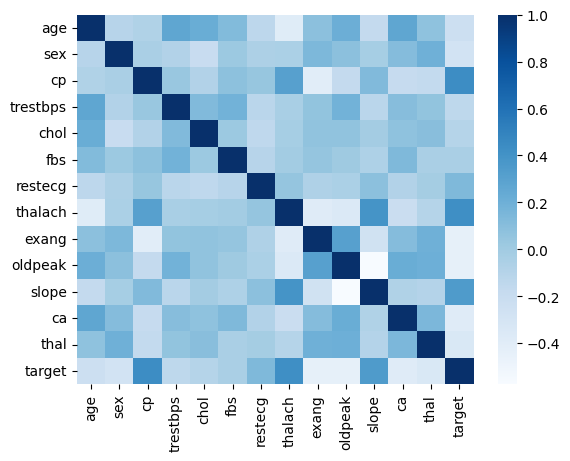

In [18]:
corr=df.corr()
sns.heatmap(corr, cmap='Blues')